<a href="https://colab.research.google.com/github/mysciz/xjtu-ml-class/blob/main/exp/code/ml-exp2-img.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 导入库并初始化设备

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
import os
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
#不在colab请注释下面两行
from google.colab import drive
drive.mount('/content/drive',force_remount=True)
# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# 检查CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

Mounted at /content/drive
使用设备: cuda


### 数据预处理与加载数据集
定义数据集类和数据加载器

In [2]:
class CIFAR10DataLoader:
    """CIFAR-10数据加载器类，统一管理数据加载、预处理和统计量计算"""

    def __init__(self, data_path, batch_size=64, num_workers=2, download=False):
        self.data_path = data_path
        self.batch_size = batch_size
        self.num_workers = num_workers

        # 计算数据集的均值和标准差（基于原始训练数据）
        self.mean, self.std = self._calculate_dataset_stats(download)

        # 创建数据加载器
        self.train_loader = None
        self.test_loader = None
        self._create_loaders()

        # 类别名称
        self.classes = ('plane', 'car', 'bird', 'cat', 'deer',
                       'dog', 'frog', 'horse', 'ship', 'truck')

    def _calculate_dataset_stats(self, download):
        """计算原始数据集的均值和标准差"""
        print("正在计算数据集的均值和标准差...")

        # 直接用transforms.ToTensor()加载原始数据
        temp_transform = transforms.Compose([transforms.ToTensor()])
        temp_dataset = torchvision.datasets.CIFAR10(
            root=self.data_path, train=True, download=download, transform=temp_transform
        )
        temp_loader = DataLoader(temp_dataset, batch_size=64, shuffle=False)

        channels_sum = 0
        channels_squared_sum = 0
        num_batches = 0

        for images, _ in temp_loader:
            channels_sum += torch.mean(images, dim=[0, 2, 3])
            channels_squared_sum += torch.mean(images ** 2, dim=[0, 2, 3])
            num_batches += 1

        mean = channels_sum / num_batches
        std = (channels_squared_sum / num_batches - mean ** 2) ** 0.5

        print(f"计算得到的均值: {mean}")
        print(f"计算得到的标准差: {std}")

        return mean, std

    def _create_loaders(self):
        """创建训练和测试数据加载器"""
        # 训练数据增强
        transform_train = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(self.mean, self.std)
        ])

        # 测试数据预处理（无增强）
        transform_test = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(self.mean, self.std)
        ])

        # 直接创建数据集，不需要额外的Dataset类
        train_dataset = torchvision.datasets.CIFAR10(
            root=self.data_path, train=True, transform=transform_train, download=True
        )
        test_dataset = torchvision.datasets.CIFAR10(
            root=self.data_path, train=False, transform=transform_test, download=True
        )

        # 创建数据加载器
        self.train_loader = DataLoader(
            train_dataset, batch_size=self.batch_size, shuffle=True,
            num_workers=self.num_workers, pin_memory=True if torch.cuda.is_available() else False
        )
        self.test_loader = DataLoader(
            test_dataset, batch_size=self.batch_size, shuffle=False,
            num_workers=self.num_workers, pin_memory=True if torch.cuda.is_available() else False
        )

    def get_train_loader(self):
        return self.train_loader

    def get_test_loader(self):
        return self.test_loader

    def set_batch_size(self, batch_size):
        """动态修改batch size"""
        if self.batch_size != batch_size:
            self.batch_size = batch_size
            self._create_loaders()
            print(f"Batch size 已更新为: {batch_size}")

    def get_stats(self):
        """返回数据的均值和标准差"""
        return self.mean, self.std
# 类别名称
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

### VGG实现

In [3]:
class VGG(nn.Module):
    def __init__(self, num_classes=10):
        super(VGG, self).__init__()

        # VGG11 配置
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(512 * 1 * 1, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# 创建 VGG 模型
vgg_model = VGG(num_classes=10).to(device)
print(vgg_model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

### ResNet实现

In [4]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = torch.relu(out)
        return out

class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet, self).__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        self.linear = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = nn.functional.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)
        out = self.linear(out)
        return out

def ResNet18():
    return ResNet(BasicBlock, [2, 2, 2, 2])

# 创建 ResNet 模型
resnet_model = ResNet18().to(device)
print(resnet_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=

### 定义Trainer

In [5]:
class ModelTrainer:
    """模型训练器类，封装训练、评估和可视化功能"""

    def __init__(self, model, device=None):
        """
        初始化训练器
        Args:
            model: 要训练的模型
            device: 计算设备，如果为None则自动选择
        """
        self.model = model
        self.device = device if device else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"Using device: {device}")
        self.model = self.model.to(self.device)

        # 训练历史记录
        self.train_losses = []
        self.train_accs = []
        self.test_accs = []
        self.test_precisions = []
        self.test_recalls = []
        self.test_f1s = []

        # 最佳模型记录
        self.best_test_acc = 0
        self.best_epoch = -1

    def train(self, train_loader, test_loader, epochs=50,
              optimizer_name='adam', lr=0.001, weight_decay=0,
              scheduler_type='cosine', class_names=None, verbose=True):
        """
        训练模型
        Args:
            train_loader: 训练数据加载器
            test_loader: 测试数据加载器
            epochs: 训练轮数
            optimizer_name: 优化器名称 ('adam', 'sgd', 'rmsprop')
            lr: 学习率
            weight_decay: 权重衰减
            scheduler_type: 学习率调度器类型 ('cosine', 'step', 'none')
            class_names: 类别名称列表，用于评估时打印
            verbose: 是否打印详细信息
        Returns:
            self: 返回自身，支持链式调用
        """
        criterion = nn.CrossEntropyLoss()

        # 选择优化器
        optimizer = self._get_optimizer(optimizer_name, lr, weight_decay)

        # 选择学习率调度器
        scheduler = self._get_scheduler(optimizer, scheduler_type, epochs)

        for epoch in range(epochs):
            # 训练一个epoch
            train_loss, train_acc = self._train_epoch(
                train_loader, criterion, optimizer, epoch, epochs, verbose
            )

            # 在测试集上评估
            test_metrics = self.evaluate(test_loader, class_names=class_names, verbose=False)

            # 记录历史
            self.train_losses.append(train_loss)
            self.train_accs.append(train_acc)
            self.test_accs.append(test_metrics['accuracy'])
            self.test_precisions.append(test_metrics['precision'])
            self.test_recalls.append(test_metrics['recall'])
            self.test_f1s.append(test_metrics['f1'])

            # 保存最佳模型
            if test_metrics['accuracy'] > self.best_test_acc:
                self.best_test_acc = test_metrics['accuracy']
                self.best_epoch = epoch + 1
                self._save_best_model()

            # 更新学习率
            if scheduler:
                scheduler.step()

            # 打印进度
            if verbose:
                current_lr = optimizer.param_groups[0]['lr']
                print(f'Epoch {epoch+1}/{epochs}: '
                      f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
                      f'Test Acc: {test_metrics["accuracy"]:.2f}%, LR: {current_lr:.6f}')

        # 训练结束，恢复最佳模型
        self._restore_best_model()

        if verbose:
            print(f"\n训练完成！最佳测试准确率: {self.best_test_acc:.2f}% (Epoch {self.best_epoch})")

        return self

    def _train_epoch(self, train_loader, criterion, optimizer, epoch, total_epochs, verbose):
        """训练一个epoch"""
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        iterator = tqdm(train_loader, desc=f'Epoch {epoch+1}/{total_epochs}') if verbose else train_loader

        for inputs, targets in iterator:
            inputs, targets = inputs.to(self.device), targets.to(self.device)

            optimizer.zero_grad()
            outputs = self.model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total

        return train_loss, train_acc

    def evaluate(self, test_loader, class_names=None, verbose=True, num_examples=5):
        """
        评估模型
        Args:
            test_loader: 测试数据加载器
            class_names: 类别名称列表
            verbose: 是否打印详细信息
            num_examples: 打印的测试案例数量
        Returns:
            dict: 包含各种评估指标的字典
        """
        self.model.eval()

        all_preds = []
        all_targets = []
        all_images = []

        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(self.device), targets.to(self.device)
                outputs = self.model(inputs)
                _, predicted = outputs.max(1)

                all_preds.extend(predicted.cpu().numpy())
                all_targets.extend(targets.cpu().numpy())

                # 保存前num_examples张图片用于展示
                if len(all_images) < num_examples:
                    remaining = num_examples - len(all_images)
                    all_images.extend(inputs[:remaining].cpu())

        # 转换为numpy数组
        all_preds = np.array(all_preds)
        all_targets = np.array(all_targets)

        # 计算各项指标
        from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

        accuracy = accuracy_score(all_targets, all_preds) * 100
        precision = precision_score(all_targets, all_preds, average='macro', zero_division=0) * 100
        recall = recall_score(all_targets, all_preds, average='macro', zero_division=0) * 100
        f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0) * 100

        # 每类的精确率和召回率
        per_class_precision = precision_score(all_targets, all_preds, average=None, zero_division=0) * 100
        per_class_recall = recall_score(all_targets, all_preds, average=None, zero_division=0) * 100

        metrics = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'per_class_precision': per_class_precision,
            'per_class_recall': per_class_recall,
            'confusion_matrix': confusion_matrix(all_targets, all_preds),
            'predictions': all_preds,
            'targets': all_targets,
            'images': all_images
        }

        if verbose:
            self._print_metrics(metrics, class_names, num_examples)

        return metrics

    def _print_metrics(self, metrics, class_names=None, num_examples=5):
        """打印评估指标和可视化结果"""
        print("\n" + "="*60)
        print("模型评估结果")
        print("="*60)
        print(f"准确率 (Accuracy): {metrics['accuracy']:.2f}%")
        print(f"宏平均精确率 (Macro Precision): {metrics['precision']:.2f}%")
        print(f"宏平均召回率 (Macro Recall): {metrics['recall']:.2f}%")
        print(f"宏平均F1分数 (Macro F1): {metrics['f1']:.2f}%")

        if class_names:
            print("\n各类别详细指标:")
            print("-"*60)
            print(f"{'类别':<12} {'精确率':<10} {'召回率':<10}")
            print("-"*60)
            for i, name in enumerate(class_names):
                print(f"{name:<12} {metrics['per_class_precision'][i]:<10.2f}% {metrics['per_class_recall'][i]:<10.2f}%")

        # 混淆矩阵
        cm = metrics['confusion_matrix']
        print("\n混淆矩阵:")
        print("-"*60)
        if class_names and len(class_names) <= 10:
            print("     " + " ".join([f"{name[:3]:>4}" for name in class_names]))
            for i in range(len(class_names)):
                print(f"{class_names[i][:3]:>4} " + " ".join([f"{cm[i,j]:>4}" for j in range(len(class_names))]))
        else:
            print(cm)

        # 可视化测试案例
        if class_names and metrics['images']:
            self._visualize_predictions(metrics, class_names, num_examples)

    def _visualize_predictions(self, metrics, class_names, num_examples):
        """可视化预测结果"""
        print("\n" + "="*60)
        print(f"测试案例展示 (共{num_examples}张)")
        print("="*60)

        fig, axes = plt.subplots(1, num_examples, figsize=(15, 3))
        if num_examples == 1:
            axes = [axes]

        # 注意：这里需要知道mean和std，可以通过参数传入
        # 或者从数据加载器获取，这里使用CIFAR-10的默认值
        mean = np.array([0.4914, 0.4822, 0.4465])
        std = np.array([0.2023, 0.1994, 0.2010])

        for i in range(num_examples):
            img = metrics['images'][i]
            img = img.numpy().transpose(1, 2, 0)
            img = img * std + mean  # 反归一化
            img = np.clip(img, 0, 1)

            axes[i].imshow(img)
            true_label = class_names[metrics['targets'][i]]
            pred_label = class_names[metrics['predictions'][i]]
            color = 'green' if metrics['targets'][i] == metrics['predictions'][i] else 'red'
            axes[i].set_title(f'True: {true_label}\nPred: {pred_label}', fontsize=10, color=color)
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()

    def plot_history(self):
        """绘制训练历史曲线"""
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        # 损失曲线
        axes[0].plot(self.train_losses, label='Train Loss', color='blue')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Training Loss')
        axes[0].legend()
        axes[0].grid(True)

        # 准确率曲线
        axes[1].plot(self.train_accs, label='Train Acc', color='blue')
        axes[1].plot(self.test_accs, label='Test Acc', color='red')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy (%)')
        axes[1].set_title('Accuracy')
        axes[1].legend()
        axes[1].grid(True)

        # 其他指标曲线
        axes[2].plot(self.test_precisions, label='Precision', color='green')
        axes[2].plot(self.test_recalls, label='Recall', color='orange')
        axes[2].plot(self.test_f1s, label='F1 Score', color='purple')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('Score (%)')
        axes[2].set_title('Test Metrics')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()

    def _get_optimizer(self, optimizer_name, lr, weight_decay):
        """获取优化器"""
        if optimizer_name.lower() == 'adam':
            return optim.Adam(self.model.parameters(), lr=lr, weight_decay=weight_decay)
        elif optimizer_name.lower() == 'sgd':
            return optim.SGD(self.model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
        elif optimizer_name.lower() == 'rmsprop':
            return optim.RMSprop(self.model.parameters(), lr=lr, weight_decay=weight_decay)
        else:
            raise ValueError(f"不支持的优化器: {optimizer_name}")

    def _get_scheduler(self, optimizer, scheduler_type, epochs):
        """获取学习率调度器"""
        if scheduler_type.lower() == 'cosine':
            return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
        elif scheduler_type.lower() == 'step':
            return optim.lr_scheduler.StepLR(optimizer, step_size=epochs//3, gamma=0.1)
        else:
            return None

    def _save_best_model(self):
        """保存最佳模型"""
        self.best_model_state = {k: v.cpu().clone() for k, v in self.model.state_dict().items()}

    def _restore_best_model(self):
        """恢复最佳模型"""
        if hasattr(self, 'best_model_state'):
            self.model.load_state_dict(self.best_model_state)
            self.model.to(self.device)

    def save_model(self, path):
        """保存模型到文件"""
        torch.save({
            'model_state_dict': self.model.state_dict(),
            'train_losses': self.train_losses,
            'train_accs': self.train_accs,
            'test_accs': self.test_accs,
            'test_precisions': self.test_precisions,
            'test_recalls': self.test_recalls,
            'test_f1s': self.test_f1s,
            'best_test_acc': self.best_test_acc,
            'best_epoch': self.best_epoch
        }, path)
        print(f"模型已保存到: {path}")

    def load_model(self, path):
        """从文件加载模型"""
        checkpoint = torch.load(path)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.train_losses = checkpoint.get('train_losses', [])
        self.train_accs = checkpoint.get('train_accs', [])
        self.test_accs = checkpoint.get('test_accs', [])
        self.test_precisions = checkpoint.get('test_precisions', [])
        self.test_recalls = checkpoint.get('test_recalls', [])
        self.test_f1s = checkpoint.get('test_f1s', [])
        self.best_test_acc = checkpoint.get('best_test_acc', 0)
        self.best_epoch = checkpoint.get('best_epoch', -1)
        print(f"模型已从: {path} 加载")

    def get_model(self):
        """返回模型"""
        return self.model

### 测试
#### RESNET18测试

正在计算数据集的均值和标准差...
计算得到的均值: tensor([0.4915, 0.4822, 0.4466])
计算得到的标准差: tensor([0.2470, 0.2435, 0.2616])
Using device: cuda


Epoch 1/50: 100%|██████████| 391/391 [00:41<00:00,  9.52it/s]


Epoch 1/50: Train Loss: 1.4429, Train Acc: 47.19%, Test Acc: 56.10%, LR: 0.009990


Epoch 2/50: 100%|██████████| 391/391 [00:41<00:00,  9.50it/s]


Epoch 2/50: Train Loss: 0.9145, Train Acc: 67.67%, Test Acc: 70.99%, LR: 0.009961


...

Epoch 48/50: Train Loss: 0.0075, Train Acc: 99.89%, Test Acc: 92.74%, LR: 0.000039


Epoch 49/50: 100%|██████████| 391/391 [00:41<00:00,  9.40it/s]


Epoch 49/50: Train Loss: 0.0069, Train Acc: 99.88%, Test Acc: 92.70%, LR: 0.000010


Epoch 50/50: 100%|██████████| 391/391 [00:41<00:00,  9.38it/s]


Epoch 50/50: Train Loss: 0.0071, Train Acc: 99.88%, Test Acc: 92.68%, LR: 0.000000

训练完成！最佳测试准确率: 92.78% (Epoch 43)


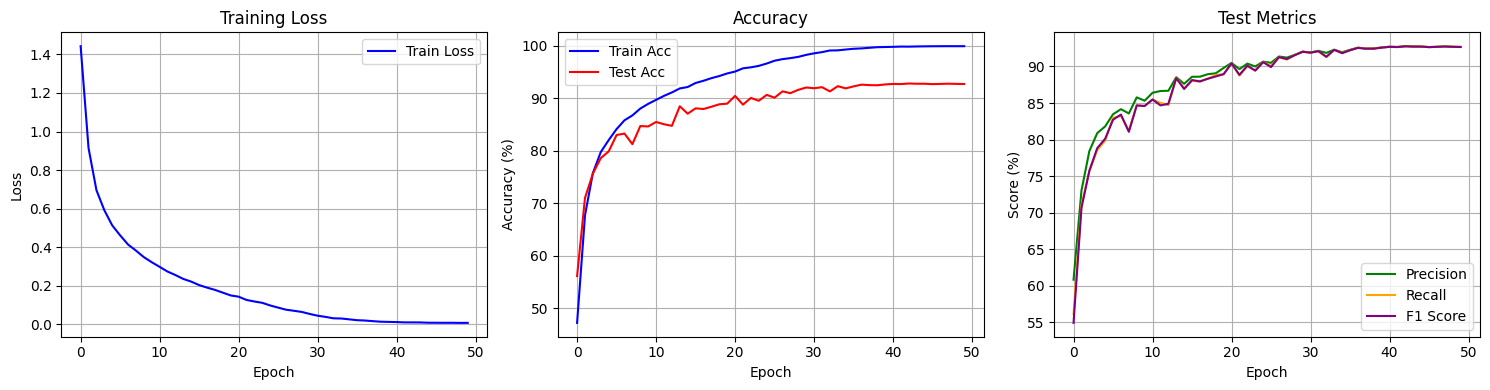


模型评估结果
准确率 (Accuracy): 92.78%
宏平均精确率 (Macro Precision): 92.77%
宏平均召回率 (Macro Recall): 92.78%
宏平均F1分数 (Macro F1): 92.77%

各类别详细指标:
------------------------------------------------------------
类别           精确率        召回率       
------------------------------------------------------------
plane        92.53     % 94.10     %
car          96.52     % 97.10     %
bird         89.20     % 90.00     %
cat          87.11     % 84.50     %
deer         91.44     % 94.00     %
dog          89.63     % 88.20     %
frog         94.69     % 94.50     %
horse        95.11     % 95.40     %
ship         96.45     % 95.00     %
truck        95.00     % 95.00     %

混淆矩阵:
------------------------------------------------------------
      pla  car  bir  cat  dee  dog  fro  hor  shi  tru
 pla  941    3   17    7    6    0    1    1   17    7
 car    5  971    0    0    0    0    0    0    2   22
 bir   18    0  900   14   25   15   19    8    1    0
 cat    6    1   25  845   24   61   19   11    4    4

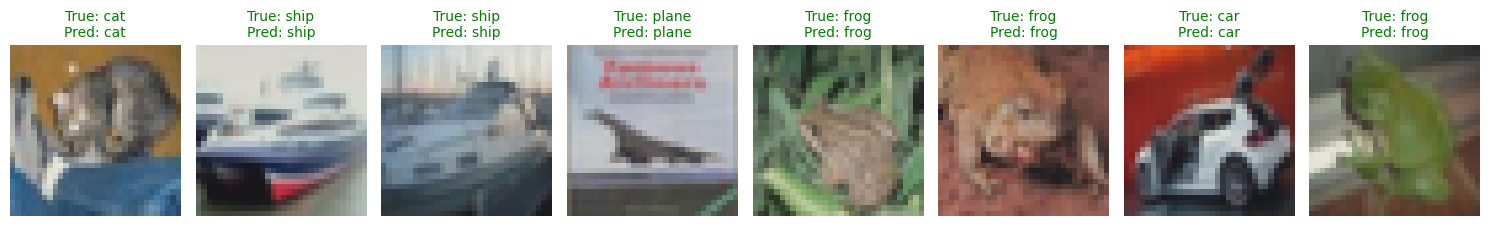

模型已保存到: ./Res18_rl1_sgd_batch128.pth


In [ ]:
data_loader = CIFAR10DataLoader(
        data_path='./xjtu-ml-class/exp/data/cifar-10-python',
        batch_size=128,
        num_workers=2
    )

# 2. 创建模型（这里以ResNet18为例）
Res18_model = ResNet18()  # 假设你已经定义了ResNet18

# 3. 创建训练器
trainer_res = ModelTrainer(Res18_model, device=device)

# 4. 训练模型
trainer_res.train(
    train_loader=data_loader.get_train_loader(),
    test_loader=data_loader.get_test_loader(),
    epochs=50,
    optimizer_name='sgd',
    lr=0.01,
    weight_decay=5e-4,
    scheduler_type='cosine',
    class_names=data_loader.classes,
    verbose=True
)

# 5. 绘制训练曲线
trainer_res.plot_history()

# 6. 最终评估
metrics = trainer_res.evaluate(
    test_loader=data_loader.get_test_loader(),
    class_names=data_loader.classes,
    verbose=True,
    num_examples=8
)

# 7. 保存模型
trainer_res.save_model('./Res18_rl1_sgd_batch128.pth')

#### VGG测试

Using device: cuda


Epoch 1/50: 100%|██████████| 391/391 [00:20<00:00, 19.03it/s]


Epoch 1/50: Train Loss: 1.4394, Train Acc: 47.11%, Test Acc: 57.68%, LR: 0.009990


Epoch 2/50: 100%|██████████| 391/391 [00:19<00:00, 19.75it/s]


Epoch 2/50: Train Loss: 0.9860, Train Acc: 65.39%, Test Acc: 65.12%, LR: 0.009961


...

Epoch 48/50: Train Loss: 0.0208, Train Acc: 99.34%, Test Acc: 90.26%, LR: 0.000039


Epoch 49/50: 100%|██████████| 391/391 [00:20<00:00, 19.42it/s]


Epoch 49/50: Train Loss: 0.0212, Train Acc: 99.34%, Test Acc: 90.29%, LR: 0.000010


Epoch 50/50: 100%|██████████| 391/391 [00:19<00:00, 20.18it/s]


Epoch 50/50: Train Loss: 0.0222, Train Acc: 99.31%, Test Acc: 90.30%, LR: 0.000000

训练完成！最佳测试准确率: 90.30% (Epoch 50)


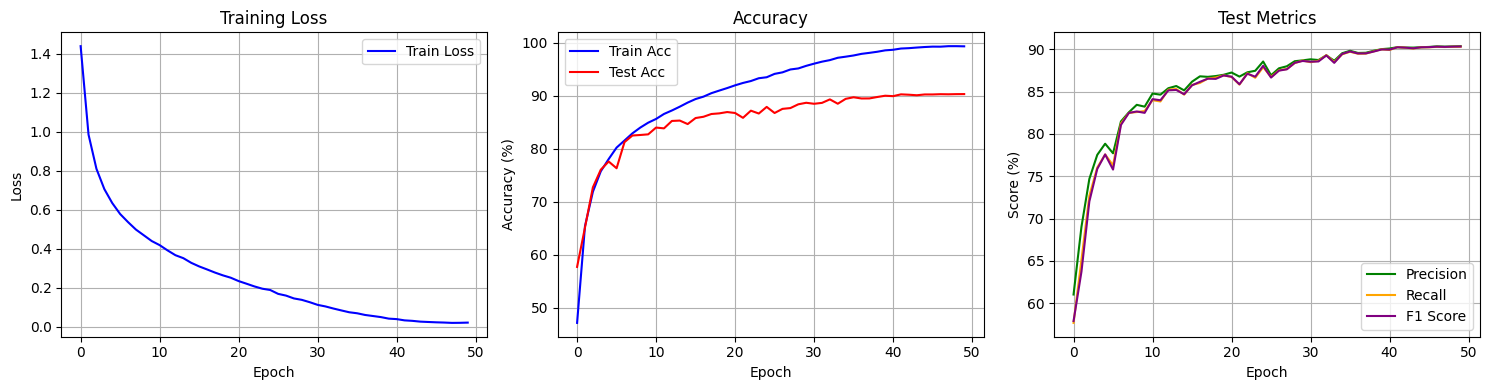


模型评估结果
准确率 (Accuracy): 90.30%
宏平均精确率 (Macro Precision): 90.36%
宏平均召回率 (Macro Recall): 90.30%
宏平均F1分数 (Macro F1): 90.32%

各类别详细指标:
------------------------------------------------------------
类别           精确率        召回率       
------------------------------------------------------------
plane        91.88     % 91.70     %
car          95.25     % 96.30     %
bird         88.25     % 87.90     %
cat          78.07     % 81.50     %
deer         89.29     % 90.00     %
dog          85.25     % 83.80     %
frog         93.05     % 92.40     %
horse        94.54     % 91.70     %
ship         95.40     % 93.30     %
truck        92.64     % 94.40     %

混淆矩阵:
------------------------------------------------------------
      pla  car  bir  cat  dee  dog  fro  hor  shi  tru
 pla  917    7   16   14    4    3    2    5   19   13
 car    2  963    1    2    0    0    1    0    4   27
 bir   11    0  879   33   23   17   21    9    6    1
 cat    6    1   26  815   30   81   21    9    3    8

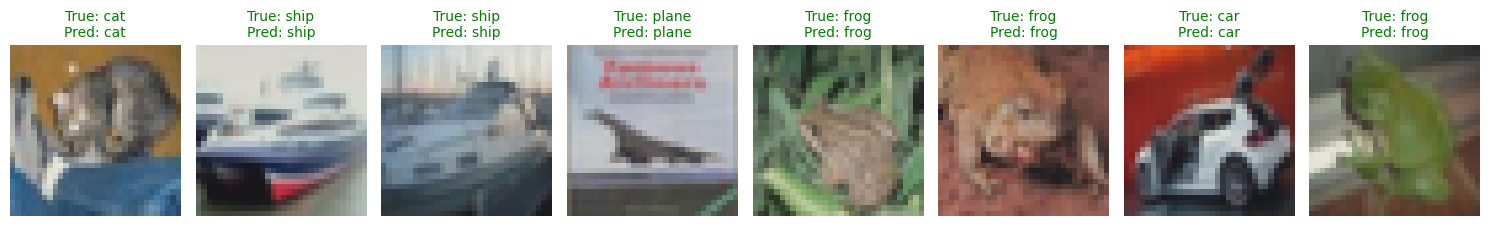

模型已保存到: ./Vgg_rl1_sgd_batch128.pth


In [ ]:
# 3. 创建训练器
trainer_vgg = ModelTrainer(vgg_model, device=device)

# 4. 训练模型
trainer_vgg.train(
    train_loader=data_loader.get_train_loader(),
    test_loader=data_loader.get_test_loader(),
    epochs=50,
    optimizer_name='sgd',
    lr=0.01,
    weight_decay=5e-4,
    scheduler_type='cosine',
    class_names=data_loader.classes,
    verbose=True
)

# 5. 绘制训练曲线
trainer_vgg.plot_history()

# 6. 最终评估
metrics = trainer_vgg.evaluate(
    test_loader=data_loader.get_test_loader(),
    class_names=data_loader.classes,
    verbose=True,
    num_examples=8
)

# 7. 保存模型
trainer_vgg.save_model('./Vgg_rl1_sgd_batch128.pth')

### 对照试验
#### 改变优化方法

Epoch 1/20: 100%|██████████| 391/391 [00:42<00:00,  9.24it/s]


Epoch 1/20: Train Loss: 1.8191, Train Acc: 33.07%, Test Acc: 44.07%, LR: 0.009938


Epoch 2/20: 100%|██████████| 391/391 [00:41<00:00,  9.37it/s]


Epoch 2/20: Train Loss: 1.3747, Train Acc: 49.53%, Test Acc: 35.94%, LR: 0.009755


Epoch 3/20: 100%|██████████| 391/391 [00:41<00:00,  9.51it/s]


...

Epoch 18/20: Train Loss: 0.5636, Train Acc: 80.56%, Test Acc: 80.07%, LR: 0.000245


Epoch 19/20: 100%|██████████| 391/391 [00:39<00:00,  9.96it/s]


Epoch 19/20: Train Loss: 0.5415, Train Acc: 81.13%, Test Acc: 80.28%, LR: 0.000062


Epoch 20/20: 100%|██████████| 391/391 [00:39<00:00,  9.96it/s]


Epoch 20/20: Train Loss: 0.5326, Train Acc: 81.64%, Test Acc: 80.72%, LR: 0.000000

训练完成！最佳测试准确率: 92.78% (Epoch 43)


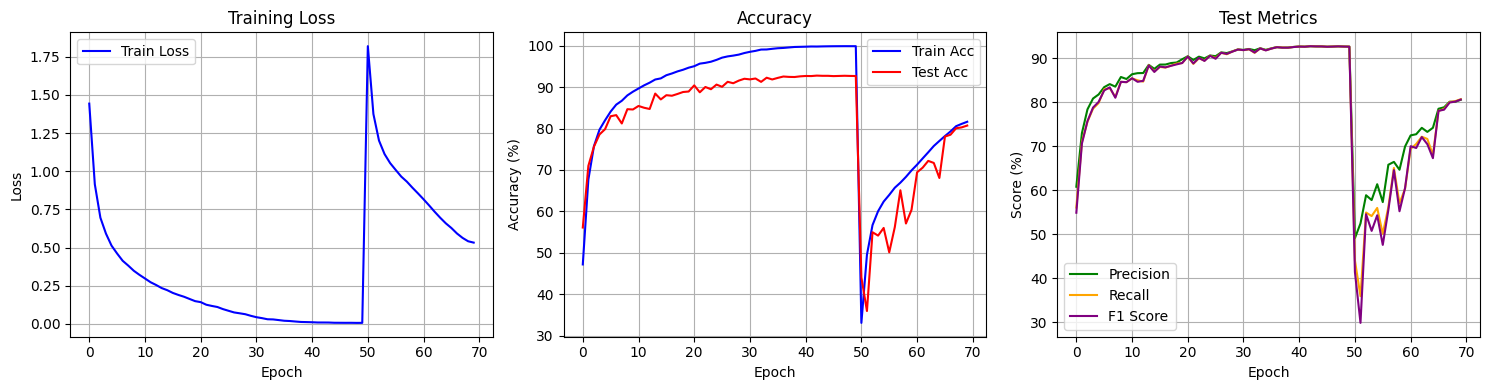


模型评估结果
准确率 (Accuracy): 92.78%
宏平均精确率 (Macro Precision): 92.77%
宏平均召回率 (Macro Recall): 92.78%
宏平均F1分数 (Macro F1): 92.77%

各类别详细指标:
------------------------------------------------------------
类别           精确率        召回率       
------------------------------------------------------------
plane        92.53     % 94.10     %
car          96.52     % 97.10     %
bird         89.20     % 90.00     %
cat          87.11     % 84.50     %
deer         91.44     % 94.00     %
dog          89.63     % 88.20     %
frog         94.69     % 94.50     %
horse        95.11     % 95.40     %
ship         96.45     % 95.00     %
truck        95.00     % 95.00     %

混淆矩阵:
------------------------------------------------------------
      pla  car  bir  cat  dee  dog  fro  hor  shi  tru
 pla  941    3   17    7    6    0    1    1   17    7
 car    5  971    0    0    0    0    0    0    2   22
 bir   18    0  900   14   25   15   19    8    1    0
 cat    6    1   25  845   24   61   19   11    4    4

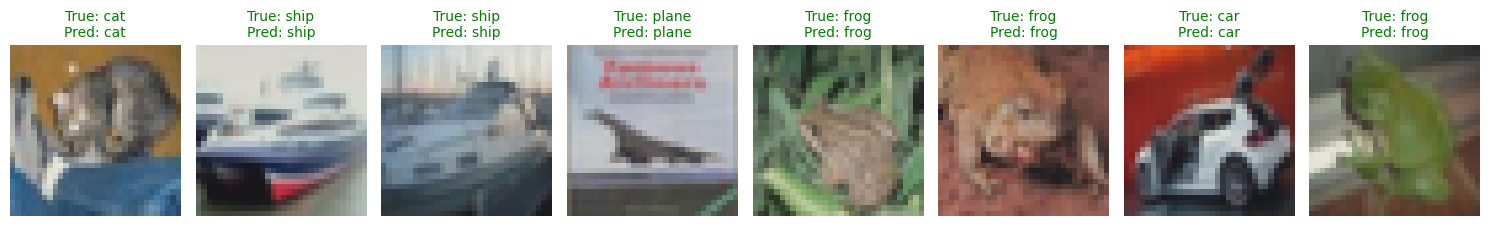

模型已保存到: ./Res18_rl1_adam_batch128.pth


In [ ]:
trainer_res2 = ModelTrainer(Res18_model, device=device)
trainer_res2.train(
    train_loader=data_loader.get_train_loader(),
    test_loader=data_loader.get_test_loader(),
    epochs=20,
    optimizer_name='adam',
    lr=0.01,
    weight_decay=5e-4,
    scheduler_type='cosine',
    class_names=data_loader.classes,
    verbose=True
)
# 5. 绘制训练曲线
trainer_res2.plot_history()

# 6. 最终评估
metrics = trainer_res2.evaluate(
    test_loader=data_loader.get_test_loader(),
    class_names=data_loader.classes,
    verbose=True,
    num_examples=8
)

# 7. 保存模型
trainer_res2.save_model('./Res18_rl1_adam_batch128.pth')

#### 改变rl

Epoch 1/50: 100%|██████████| 391/391 [00:19<00:00, 20.09it/s]


Epoch 1/50: Train Loss: 0.8721, Train Acc: 70.80%, Test Acc: 73.50%, LR: 0.049951


Epoch 2/50: 100%|██████████| 391/391 [00:20<00:00, 19.54it/s]


Epoch 2/50: Train Loss: 0.6119, Train Acc: 79.82%, Test Acc: 79.57%, LR: 0.049803


Epoch 3/50: 100%|██████████| 391/391 [00:18<00:00, 20.76it/s]


...

Epoch 48/50: Train Loss: 0.0118, Train Acc: 99.66%, Test Acc: 91.59%, LR: 0.000197


Epoch 49/50: 100%|██████████| 391/391 [00:18<00:00, 20.70it/s]


Epoch 49/50: Train Loss: 0.0114, Train Acc: 99.66%, Test Acc: 91.47%, LR: 0.000049


Epoch 50/50: 100%|██████████| 391/391 [00:19<00:00, 19.62it/s]


Epoch 50/50: Train Loss: 0.0097, Train Acc: 99.72%, Test Acc: 91.57%, LR: 0.000000

训练完成！最佳测试准确率: 91.59% (Epoch 48)


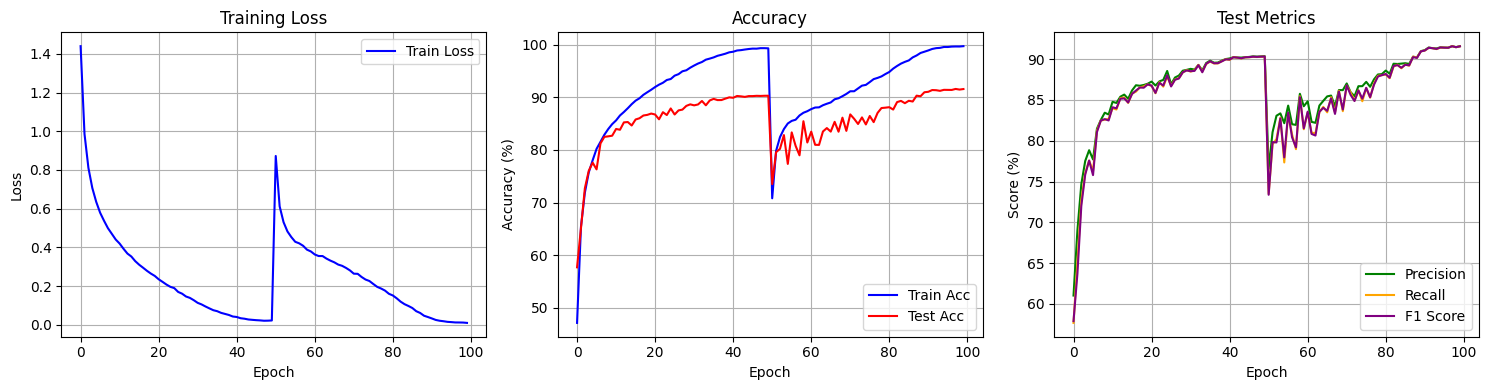


模型评估结果
准确率 (Accuracy): 91.59%
宏平均精确率 (Macro Precision): 91.59%
宏平均召回率 (Macro Recall): 91.59%
宏平均F1分数 (Macro F1): 91.59%

各类别详细指标:
------------------------------------------------------------
类别           精确率        召回率       
------------------------------------------------------------
plane        91.94     % 92.40     %
car          95.63     % 96.20     %
bird         90.02     % 88.40     %
cat          82.67     % 83.50     %
deer         91.24     % 91.70     %
dog          87.20     % 85.80     %
frog         93.28     % 94.40     %
horse        94.04     % 94.70     %
ship         95.10     % 95.20     %
truck        94.74     % 93.60     %

混淆矩阵:
------------------------------------------------------------
      pla  car  bir  cat  dee  dog  fro  hor  shi  tru
 pla  924    3   18    8    5    1    4    5   23    9
 car    3  962    0    3    0    0    1    1    6   24
 bir   15    0  884   25   23   18   18   10    5    2
 cat    9    1   23  835   20   70   26    9    5    2

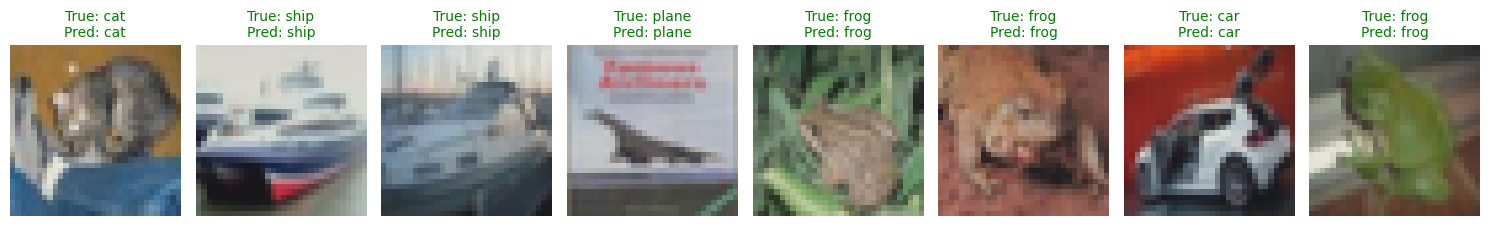

模型已保存到: ./Vgg_rl5_sgd_batch128.pth


In [ ]:
trainer_vgg2 = ModelTrainer(vgg_model, device=device)
# 4. 训练模型
trainer_vgg2.train(
    train_loader=data_loader.get_train_loader(),
    test_loader=data_loader.get_test_loader(),
    epochs=50,
    optimizer_name='sgd',
    lr=0.05,
    weight_decay=5e-4,
    scheduler_type='cosine',
    class_names=data_loader.classes,
    verbose=True
)

# 5. 绘制训练曲线
trainer_vgg2.plot_history()

# 6. 最终评估
metrics = trainer_vgg2.evaluate(
    test_loader=data_loader.get_test_loader(),
    class_names=data_loader.classes,
    verbose=True,
    num_examples=8
)

# 7. 保存模型
trainer_vgg2.save_model('./Vgg_rl5_sgd_batch128.pth')

正在计算数据集的均值和标准差...
计算得到的均值: tensor([0.4915, 0.4822, 0.4466])
计算得到的标准差: tensor([0.2470, 0.2435, 0.2616])
Using device: cuda


Epoch 1/50: 100%|██████████| 196/196 [00:42<00:00,  4.60it/s]


Epoch 1/50: Train Loss: 0.0443, Train Acc: 98.50%, Test Acc: 89.65%, LR: 0.009990


Epoch 2/50: 100%|██████████| 196/196 [00:40<00:00,  4.90it/s]


Epoch 2/50: Train Loss: 0.0769, Train Acc: 97.22%, Test Acc: 89.15%, LR: 0.009961


...

Epoch 48/50: Train Loss: 0.0016, Train Acc: 100.00%, Test Acc: 93.16%, LR: 0.000039


Epoch 49/50: 100%|██████████| 196/196 [00:40<00:00,  4.87it/s]


Epoch 49/50: Train Loss: 0.0016, Train Acc: 99.99%, Test Acc: 93.17%, LR: 0.000010


Epoch 50/50: 100%|██████████| 196/196 [00:40<00:00,  4.86it/s]


Epoch 50/50: Train Loss: 0.0015, Train Acc: 99.99%, Test Acc: 93.18%, LR: 0.000000

训练完成！最佳测试准确率: 93.29% (Epoch 33)


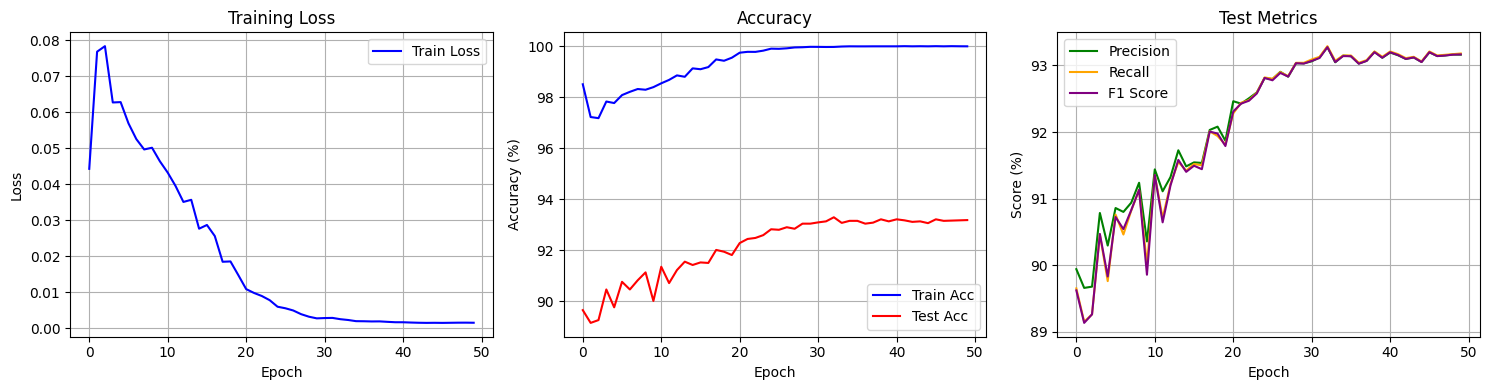


模型评估结果
准确率 (Accuracy): 93.29%
宏平均精确率 (Macro Precision): 93.28%
宏平均召回率 (Macro Recall): 93.29%
宏平均F1分数 (Macro F1): 93.28%

各类别详细指标:
------------------------------------------------------------
类别           精确率        召回率       
------------------------------------------------------------
plane        92.59     % 95.00     %
car          96.35     % 97.70     %
bird         92.67     % 89.80     %
cat          86.36     % 84.20     %
deer         92.82     % 94.40     %
dog          89.07     % 89.60     %
frog         94.65     % 95.60     %
horse        95.80     % 95.90     %
ship         96.67     % 95.70     %
truck        95.77     % 95.00     %

混淆矩阵:
------------------------------------------------------------
      pla  car  bir  cat  dee  dog  fro  hor  shi  tru
 pla  950    4    9    9    5    0    0    2   14    7
 car    5  977    0    0    0    0    0    0    1   17
 bir   18    0  898   20   19   16   19    7    3    0
 cat   10    1   16  842   21   69   23   10    3    5

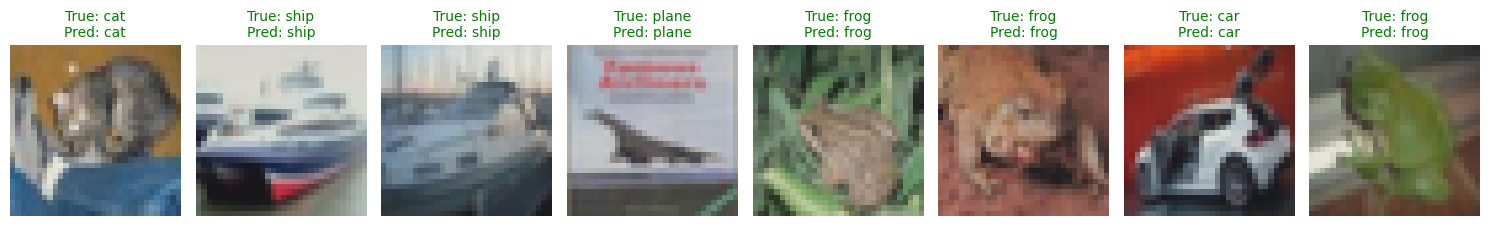

模型已保存到: ./Res18_rl1_sgd_batch128.pth


In [ ]:
data_loader = CIFAR10DataLoader(
        data_path='./xjtu-ml-class/exp/data/cifar-10-python',
        batch_size=256,
        num_workers=2
    )
trainer_res3 = ModelTrainer(Res18_model, device=device)
trainer_res3.train(
    train_loader=data_loader.get_train_loader(),
    test_loader=data_loader.get_test_loader(),
    epochs=50,
    optimizer_name='sgd',
    lr=0.01,
    weight_decay=5e-4,
    scheduler_type='cosine',
    class_names=data_loader.classes,
    verbose=True
)
trainer_res3.plot_history()
metrics = trainer_res3.evaluate(
    test_loader=data_loader.get_test_loader(),
    class_names=data_loader.classes,
    verbose=True,
    num_examples=8
)
trainer_res3.save_model('./Res18_rl1_sgd_batch128.pth')

### 增补以保存checkpoint

正在计算数据集的均值和标准差...
计算得到的均值: tensor([0.4915, 0.4822, 0.4466])
计算得到的标准差: tensor([0.2470, 0.2435, 0.2616])
Using device: cuda


Epoch 1/50: 100%|██████████| 391/391 [00:42<00:00,  9.31it/s]


Epoch 1/50: Train Loss: 1.4411, Train Acc: 47.25%, Test Acc: 60.57%, LR: 0.009990


Epoch 2/50: 100%|██████████| 391/391 [00:47<00:00,  8.26it/s]


Epoch 2/50: Train Loss: 0.9277, Train Acc: 67.07%, Test Acc: 69.78%, LR: 0.009961


...

Epoch 48/50: Train Loss: 0.0076, Train Acc: 99.87%, Test Acc: 92.77%, LR: 0.000039


Epoch 49/50: 100%|██████████| 391/391 [00:47<00:00,  8.15it/s]


Epoch 49/50: Train Loss: 0.0072, Train Acc: 99.89%, Test Acc: 92.79%, LR: 0.000010


Epoch 50/50: 100%|██████████| 391/391 [00:48<00:00,  8.11it/s]


Epoch 50/50: Train Loss: 0.0073, Train Acc: 99.90%, Test Acc: 92.79%, LR: 0.000000

训练完成！最佳测试准确率: 92.88% (Epoch 46)


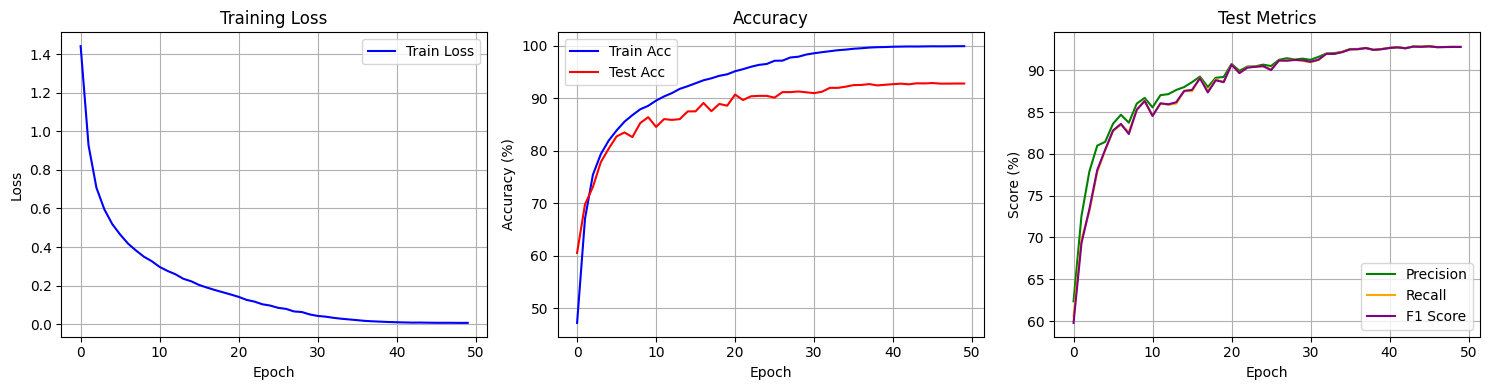


模型评估结果
准确率 (Accuracy): 92.88%
宏平均精确率 (Macro Precision): 92.86%
宏平均召回率 (Macro Recall): 92.88%
宏平均F1分数 (Macro F1): 92.86%

各类别详细指标:
------------------------------------------------------------
类别           精确率        召回率       
------------------------------------------------------------
plane        92.71     % 94.10     %
car          96.23     % 97.10     %
bird         90.15     % 90.60     %
cat          85.55     % 84.10     %
deer         91.38     % 94.40     %
dog          89.71     % 86.30     %
frog         94.36     % 95.40     %
horse        96.06     % 95.00     %
ship         95.92     % 96.40     %
truck        96.56     % 95.40     %

混淆矩阵:
------------------------------------------------------------
      pla  car  bir  cat  dee  dog  fro  hor  shi  tru
 pla  941    4   13    7    2    2    1    1   23    6
 car    7  971    0    0    2    0    0    2    2   16
 bir   13    0  906   22   24    9   21    3    1    1
 cat    9    0   24  841   26   64   23    7    5    1

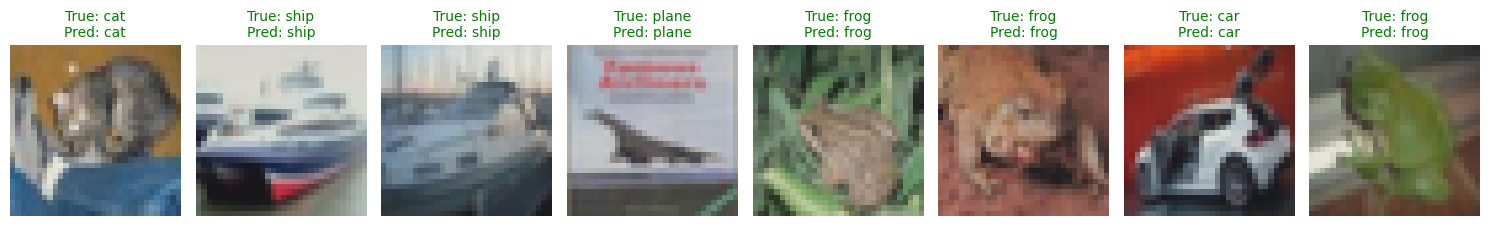

模型已保存到: /content/drive/MyDrive/Res18_lr1_sgd_batch128.pth


In [6]:
data_loader = CIFAR10DataLoader(
        data_path='./xjtu-ml-class/exp/data/cifar-10-python',
        batch_size=128,
        num_workers=2
    )

# 2. 创建模型（这里以ResNet18为例）
Res18_model = ResNet18()  # 假设你已经定义了ResNet18

# 3. 创建训练器
trainer_res = ModelTrainer(Res18_model, device=device)

# 4. 训练模型
trainer_res.train(
    train_loader=data_loader.get_train_loader(),
    test_loader=data_loader.get_test_loader(),
    epochs=50,
    optimizer_name='sgd',
    lr=0.01,
    weight_decay=5e-4,
    scheduler_type='cosine',
    class_names=data_loader.classes,
    verbose=True
)

# 5. 绘制训练曲线
trainer_res.plot_history()

# 6. 最终评估
metrics = trainer_res.evaluate(
    test_loader=data_loader.get_test_loader(),
    class_names=data_loader.classes,
    verbose=True,
    num_examples=8
)

# 7. 保存模型
trainer_res.save_model('/content/drive/MyDrive/Res18_lr1_sgd_batch128.pth')

Using device: cuda


Epoch 1/50: 100%|██████████| 391/391 [00:21<00:00, 18.62it/s]


Epoch 1/50: Train Loss: 1.4359, Train Acc: 47.08%, Test Acc: 57.79%, LR: 0.009990


Epoch 2/50: 100%|██████████| 391/391 [00:20<00:00, 19.23it/s]


Epoch 2/50: Train Loss: 0.9738, Train Acc: 66.00%, Test Acc: 65.58%, LR: 0.009961


...

Epoch 48/50: Train Loss: 0.0222, Train Acc: 99.31%, Test Acc: 90.40%, LR: 0.000039


Epoch 49/50: 100%|██████████| 391/391 [00:20<00:00, 19.04it/s]


Epoch 49/50: Train Loss: 0.0216, Train Acc: 99.34%, Test Acc: 90.48%, LR: 0.000010


Epoch 50/50: 100%|██████████| 391/391 [00:21<00:00, 17.81it/s]


Epoch 50/50: Train Loss: 0.0213, Train Acc: 99.33%, Test Acc: 90.47%, LR: 0.000000

训练完成！最佳测试准确率: 90.48% (Epoch 49)


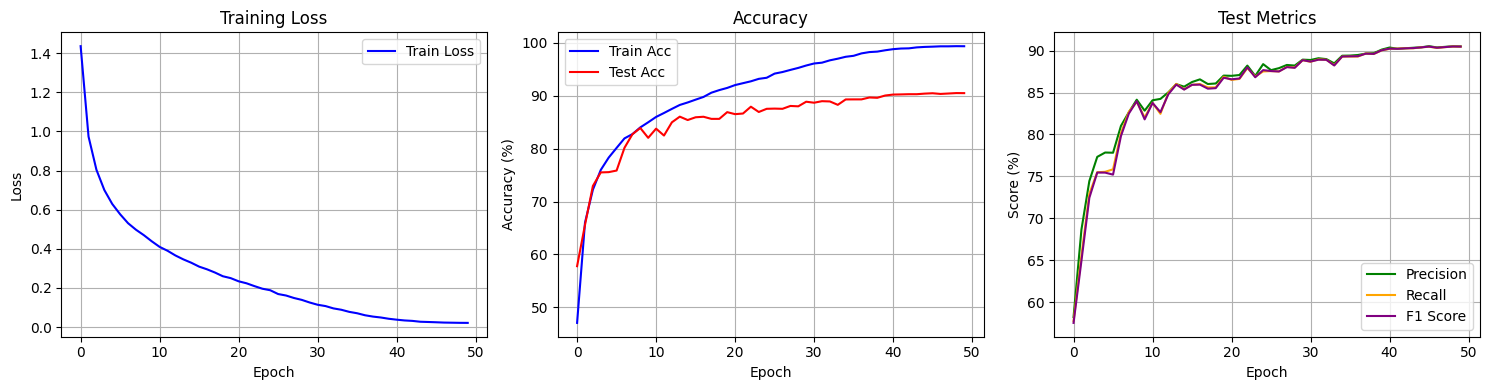


模型评估结果
准确率 (Accuracy): 90.48%
宏平均精确率 (Macro Precision): 90.51%
宏平均召回率 (Macro Recall): 90.48%
宏平均F1分数 (Macro F1): 90.48%

各类别详细指标:
------------------------------------------------------------
类别           精确率        召回率       
------------------------------------------------------------
plane        91.54     % 93.10     %
car          96.16     % 95.20     %
bird         89.43     % 86.30     %
cat          80.71     % 79.90     %
deer         87.73     % 91.50     %
dog          83.63     % 85.30     %
frog         94.60     % 92.80     %
horse        93.71     % 92.40     %
ship         94.69     % 94.50     %
truck        92.87     % 93.80     %

混淆矩阵:
------------------------------------------------------------
      pla  car  bir  cat  dee  dog  fro  hor  shi  tru
 pla  931    4   14    8    7    1    1    3   20   11
 car    5  952    1    2    0    2    0    1    6   31
 bir   17    0  863   36   33   25   10   10    5    1
 cat    8    0   26  799   31   91   21   11    6    7

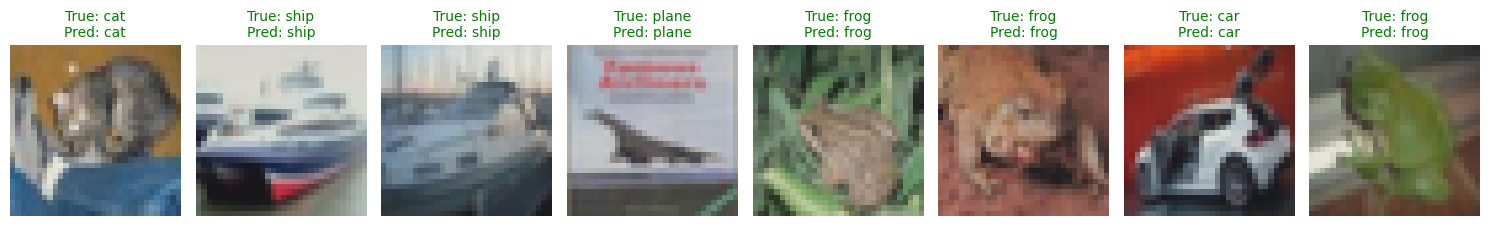

模型已保存到: /content/drive/MyDrive/vgg_lr1_sgd_batch128.pth


In [7]:
# 3. 创建训练器
trainer_vgg = ModelTrainer(vgg_model, device=device)

# 4. 训练模型
trainer_vgg.train(
    train_loader=data_loader.get_train_loader(),
    test_loader=data_loader.get_test_loader(),
    epochs=50,
    optimizer_name='sgd',
    lr=0.01,
    weight_decay=5e-4,
    scheduler_type='cosine',
    class_names=data_loader.classes,
    verbose=True
)

# 5. 绘制训练曲线
trainer_vgg.plot_history()

# 6. 最终评估
metrics = trainer_vgg.evaluate(
    test_loader=data_loader.get_test_loader(),
    class_names=data_loader.classes,
    verbose=True,
    num_examples=8
)

# 7. 保存模型
trainer_vgg.save_model('/content/drive/MyDrive/vgg_lr1_sgd_batch128.pth')